## Linear Regression for Diabetes dataset - Lesson 1

Import needed libraries

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Define the path for your new directory in Google Drive
# You can change 'MyColabNotebooks' to any name you prefer
notebook_dir = '/content/drive/MyDrive/ML-For-Beginners'

# Create the directory if it doesn't already exist
os.makedirs(notebook_dir, exist_ok=True)

# Change the current working directory to the new directory
os.chdir(notebook_dir)

print(f"Current working directory set to: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current working directory set to: /content/drive/MyDrive/ML-For-Beginners


In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model, model_selection

Load the diabetes dataset, divided into `X` data and `y` features

In [16]:
X, y = datasets.load_diabetes(return_X_y=True)
print(X.shape)
print(X)

(442, 10)
[[ 0.03807591  0.05068012  0.06169621 ... -0.00259226  0.01990749
  -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 ... -0.03949338 -0.06833155
  -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 ... -0.00259226  0.00286131
  -0.02593034]
 ...
 [ 0.04170844  0.05068012 -0.01590626 ... -0.01107952 -0.04688253
   0.01549073]
 [-0.04547248 -0.04464164  0.03906215 ...  0.02655962  0.04452873
  -0.02593034]
 [-0.04547248 -0.04464164 -0.0730303  ... -0.03949338 -0.00422151
   0.00306441]]


Select just one feature to target for this exercise

In [17]:
# Selecting the 3rd feature
X = X[:, 2]
print(X.shape)
print(X)

(442,)
[ 0.06169621 -0.05147406  0.04445121 -0.01159501 -0.03638469 -0.04069594
 -0.04716281 -0.00189471  0.06169621  0.03906215 -0.08380842  0.01750591
 -0.02884001 -0.00189471 -0.02560657 -0.01806189  0.04229559  0.01211685
 -0.0105172  -0.01806189 -0.05686312 -0.02237314 -0.00405033  0.06061839
  0.03582872 -0.01267283 -0.07734155  0.05954058 -0.02129532 -0.00620595
  0.04445121 -0.06548562  0.12528712 -0.05039625 -0.06332999 -0.03099563
  0.02289497  0.01103904  0.07139652  0.01427248 -0.00836158 -0.06764124
 -0.0105172  -0.02345095  0.06816308 -0.03530688 -0.01159501 -0.0730303
 -0.04177375  0.01427248 -0.00728377  0.0164281  -0.00943939 -0.01590626
  0.0250506  -0.04931844  0.04121778 -0.06332999 -0.06440781 -0.02560657
 -0.00405033  0.00457217 -0.00728377 -0.0374625  -0.02560657 -0.02452876
 -0.01806189 -0.01482845 -0.02991782 -0.046085   -0.06979687  0.03367309
 -0.00405033 -0.02021751  0.00241654 -0.03099563  0.02828403 -0.03638469
 -0.05794093 -0.0374625   0.01211685 -0.02237

In [18]:
#Reshaping to get a 2D array
X = X.reshape(-1, 1)
print(X.shape)
print(X)

(442, 1)
[[ 0.06169621]
 [-0.05147406]
 [ 0.04445121]
 [-0.01159501]
 [-0.03638469]
 [-0.04069594]
 [-0.04716281]
 [-0.00189471]
 [ 0.06169621]
 [ 0.03906215]
 [-0.08380842]
 [ 0.01750591]
 [-0.02884001]
 [-0.00189471]
 [-0.02560657]
 [-0.01806189]
 [ 0.04229559]
 [ 0.01211685]
 [-0.0105172 ]
 [-0.01806189]
 [-0.05686312]
 [-0.02237314]
 [-0.00405033]
 [ 0.06061839]
 [ 0.03582872]
 [-0.01267283]
 [-0.07734155]
 [ 0.05954058]
 [-0.02129532]
 [-0.00620595]
 [ 0.04445121]
 [-0.06548562]
 [ 0.12528712]
 [-0.05039625]
 [-0.06332999]
 [-0.03099563]
 [ 0.02289497]
 [ 0.01103904]
 [ 0.07139652]
 [ 0.01427248]
 [-0.00836158]
 [-0.06764124]
 [-0.0105172 ]
 [-0.02345095]
 [ 0.06816308]
 [-0.03530688]
 [-0.01159501]
 [-0.0730303 ]
 [-0.04177375]
 [ 0.01427248]
 [-0.00728377]
 [ 0.0164281 ]
 [-0.00943939]
 [-0.01590626]
 [ 0.0250506 ]
 [-0.04931844]
 [ 0.04121778]
 [-0.06332999]
 [-0.06440781]
 [-0.02560657]
 [-0.00405033]
 [ 0.00457217]
 [-0.00728377]
 [-0.0374625 ]
 [-0.02560657]
 [-0.02452876]
 

Split the training and test data for both `X` and `y`

In [21]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.33)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(296, 1)
(146, 1)
(296,)
(146,)


Select the model and fit it with the training data

In [24]:
model = linear_model.LinearRegression()
model.fit(X_train, y_train)
print(model)

LinearRegression()


Use test data to predict a line

In [25]:
y_pred = model.predict(X_test)
print(y_pred)

[159.7287224   87.91052969 155.62482567 133.05339368 144.33910968
 140.23521295 159.7287224  201.79366385 208.97548312 206.92353475
 142.28716131  69.44299442 165.88456749 136.13131622 214.10535403
 120.7417035  106.37806495 114.58585841 259.24821802 250.01445038
  83.80663296 111.50793586 145.36508386  95.09234896 183.32612858
 166.91054167  87.91052969 125.87157441 115.61183259 111.50793586
 238.72873438 255.14432129 199.74171548 121.76767768 126.89754859
 177.17028349 143.31313549 104.32611659  87.91052969 188.45599949
 182.3001544  175.11833512 107.40403914 175.11833512 144.33910968
 145.36508386 135.10534204 194.61184457 135.10534204 154.59885149
 146.39105804 179.22223185 156.65079985 126.89754859 153.57287731
 126.89754859 191.53392203 136.13131622 312.59887546 203.84561221
 239.75470857 192.55989621 172.04041258 156.65079985 141.26118713
 132.0274195  120.7417035  119.71572932 182.3001544  160.75469658
 215.13132821 207.94950894 218.20925075 131.00144531 125.87157441
 144.33910

Display the results in a plot

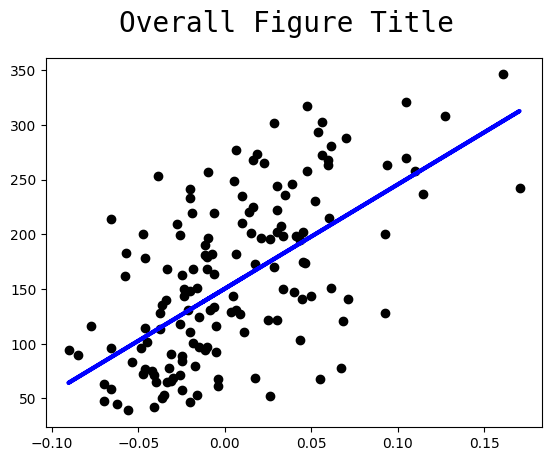

In [37]:
fig, ax = plt.subplots()
fig.suptitle('Overall Figure Title', fontsize=20, fontfamily='monospace') # Changed font family here: 'serif', 'sans-serif', 'monospace'
ax.scatter(X_test, y_test,  color='black')
ax.plot(X_test, y_pred, color='blue', linewidth=3)
plt.show()